In [9]:
import qutip as qt
import numpy as np
import scipy as sp
import matplotlib
import matplotlib.pyplot as plt
import os
import math

#plt.rcParams['text.usetex'] = True
#rfont = {'fontname':'Times New Roman'}
matplotlib.rcParams.update(matplotlib.rcParamsDefault)

# Spin matrix
S0 = qt.qeye(3)                                                # {1, 0, -1}
Sx, Sy, Sz = qt.jmat(1)                                        # {1, 0, -1}
sigma0 = qt.qeye(2)                                            # {Ex, Ey}
sigmax, sigmay, sigmaz = qt.sigmax(), qt.sigmay(), qt.sigmaz() # {Ex, Ey}

# Physics constant
h             = 6.626e-34        # J/Hz
muB           = 9.274e-24 / h    # Hz/T
Des_para      = 1.42e9           # Hz       # [Doherty 2013], 1.44e9[Bassett 2014] 
Des_perp      = 1.55e9/2         # Hz       # [Doherty 2013], 1.541e9[Bassett 2014] 
lambdaes_para = 5.3e9            # Hz       # [Doherty 2013], 5.33e9[Bassett 2014]
lambdaes_perp = 0.2e9/np.sqrt(2) # Hz       # [Doherty 2013]
des_para      = 6e3              # Hz/(V/m) # [Doherty 2013]?
des_perp      = 6e3              # Hz/(V/m) # [Doherty 2013]?
les_para      = 0.1              # 1        # [Doherty 2013], 0.05[Bassett 2014] at 1.5K
ges_para      = 2.01             # 1        # [Doherty 2013], 2.15[Bassett 2014]
ges_perp      = 2.01             # 1        # [Doherty 2013]
gamma_e       = muB * ges_para

We difine Hamiltonian in excited state as the below

In [3]:
# bare Hamiltonian
H_es = Des_para * qt.tensor(sigma0, Sz**2 - 2/3 * S0) \
       - lambdaes_para * qt.tensor(sigmay, Sz) \
       + Des_perp * (qt.tensor(sigmaz, Sy**2 - Sx**2) - qt.tensor(sigmax, Sy * Sx + Sx * Sy)) \
       + lambdaes_perp * (qt.tensor(sigmaz, Sx * Sz + Sz * Sx) - qt.tensor(sigmax, Sy * Sz + Sz * Sy))

# Interaction Hamiltonian
def V_es(E, B, delta):
    return des_para * (E[2] + delta[2]) * qt.tensor(sigma0, S0) \
           + des_perp * (E[0] + delta[0]) * qt.tensor(sigmaz, S0) \
           - des_perp * (E[1] + delta[1]) * qt.tensor(sigmax, S0) \
           + muB * (les_para * qt.tensor(sigmay, S0) + ges_para * qt.tensor(sigma0, Sz)) * B[2] \
           + muB * ges_perp * qt.tensor(sigma0, Sx * B[0] + Sy * B[1])


### stream line

1. Decpmpose eigenstates besed on spin basis
2. Extracting the amplitude coresponded to spin basis, resoectuvily
3. Define condition value ,Xi, which can reflect how spin basis are mixed , 
4. plot the normalized Xi  , sweeping magneticfield(para) and strain(perp)

In [11]:
# Decompostion of eigenstates based on spin basis
def Decomposition(H_tot):
    ee, ev = H_tot.eigenstates()
    ev_amp = [abs(evi.full()) for evi in ev][::-1]

    return ev_amp


# condition value
def Xi(List,i,j):
    a_i = List[i-1]
    a_j = List[j-1]

    return ( abs( abs(a_i)-abs(a_j) ) )/(abs(a_i) + abs(a_j) )

def Xi_pro(List, i, j):
    a_i = List[i-1]
    a_j = List[j-1]

    return (abs(a_i))**2 * (abs(a_j))**2

# extraction fot key 
def get_key_from_value(d, val):
    keys = [k for k, v in d.items() if v == val]
    if keys:
        return keys[0]
    return None

# Ductionary of ES and spin basis
Es = {'|A_2>': 0,'|A_1>': 1,'|E_x>': 2,'|E_y>': 3,'|E_1>': 4,'|E_2>': 5 }


key1 = get_key_from_value(Es, 1)

In [16]:

# mapping function 
def map_spin_fun_Xi(Number_Es):
    # Meshgrid parameters
    E = [0, 0, 0]
    strain_perp_values = np.linspace(0, 100e9, 100)
    Bz_values = np.linspace(0, 1000e-4, 100)

    # Allocate result matrix for score 
    score_map = np.zeros((len(strain_perp_values), len(Bz_values)))

    # Evaluate 1/diff over parameter space
    for k, strain_perp in enumerate(strain_perp_values):
        deltax = deltay = strain_perp / np.sqrt(2) / des_perp
        strain = [deltax, deltay, 0]

        for w, Bz in enumerate(Bz_values):
            B = [0, 0, Bz]
            H_tot = H_es + V_es(E, B, strain)

            amp_list = Decomposition(H_tot)[Number_Es]  

            score = 0.0

            for i in range(6):

                for j in range(i+1,6):
                    diff = Xi(amp_list, i, j)           # Xi between i and j components
                    # To avoid dividing by very small numbers, clamp diff
                    if diff < 1e-2:
                        diff = 1e-2
                    score += (1e9/diff)
            score_map[k, w] = math.log10(score)


    # converting spin_number => ES
    E_state = get_key_from_value(Es, Number_Es)
    
    # Plotting the heatmap
    plt.figure(figsize=(8, 6))
    plt.imshow(score_map.T, extent=[strain_perp_values[0]/1e9, strain_perp_values[-1]/1e9, 
                            Bz_values[0]*1e3, Bz_values[-1]*1e3],
            origin='lower', aspect='auto', cmap='viridis')

    plt.colorbar(label='score')
    plt.xlabel('Strain_perp (GHz)')
    plt.ylabel('Bz (mT)')
    plt.title('Mixture of spin basis in %s'  %(E_state))
    plt.tight_layout()
    plt.show()

In [17]:

# mapping function 
def map_spin_fun_Xi_pro(Number_Es):
    # Meshgrid parameters
    E = [0, 0, 0]
    strain_perp_values = np.linspace(0, 100e9, 100)
    Bz_values = np.linspace(0, 1000e-4, 100)

    # Allocate result matrix for score 
    score_map = np.zeros((len(strain_perp_values), len(Bz_values)))

    # Evaluate 1/diff over parameter space
    for k, strain_perp in enumerate(strain_perp_values):
        deltax = deltay = strain_perp / np.sqrt(2) / des_perp
        strain = [deltax, deltay, 0]

        for w, Bz in enumerate(Bz_values):
            B = [0, 0, Bz]
            H_tot = H_es + V_es(E, B, strain)

            amp_list = Decomposition(H_tot)[Number_Es]  

            score = 0.0

            for i in range(6):
                for j in range(i+1,6):
                    diff = Xi_pro(amp_list, i, j)
                    score += diff
            score_map[k, w] = score


    # converting spin_number => ES
    E_state = get_key_from_value(Es, Number_Es)
    
    # Plotting the heatmap
    plt.figure(figsize=(8, 6))
    plt.imshow(score_map.T, extent=[strain_perp_values[0]/1e9, strain_perp_values[-1]/1e9, 
                            Bz_values[0]*1e3, Bz_values[-1]*1e3],
            origin='lower', aspect='auto', cmap='viridis')

    plt.colorbar(label='score')
    plt.xlabel('Strain_perp (GHz)')
    plt.ylabel('Bz (mT)')
    plt.title('Mixture of spin basis in %s'  %(E_state))
    plt.tight_layout()
    plt.show()

C:\Users\Tsuchiya Saki\AppData\Local\Temp\ipykernel_24996\2511336360.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  score_map[k, w] = math.log10(score)


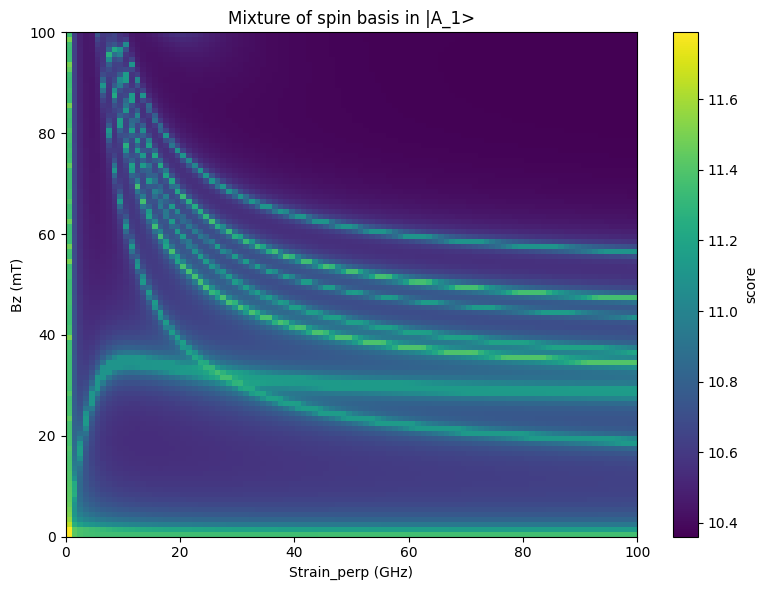

C:\Users\Tsuchiya Saki\AppData\Local\Temp\ipykernel_24996\3425506481.py:28: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  score_map[k, w] = score


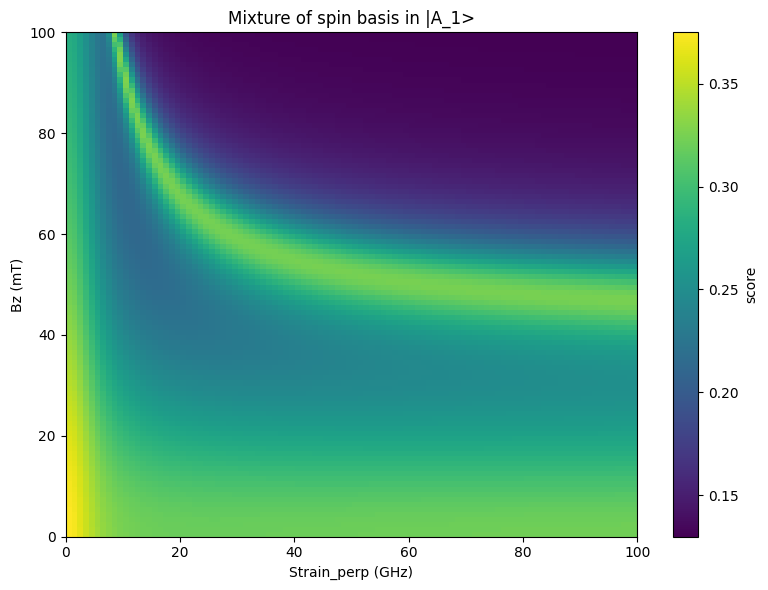

In [19]:
#{'|A_2>': 0,'|A_1>': 1,'|E_x>': 2,'|E_y>': 3,'|E_1>': 4,'|E_2>': 5 }
map_spin_fun_Xi(1)
map_spin_fun_Xi_pro(1)

C:\Users\Tsuchiya Saki\AppData\Local\Temp\ipykernel_24996\2511336360.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  score_map[k, w] = math.log10(score)


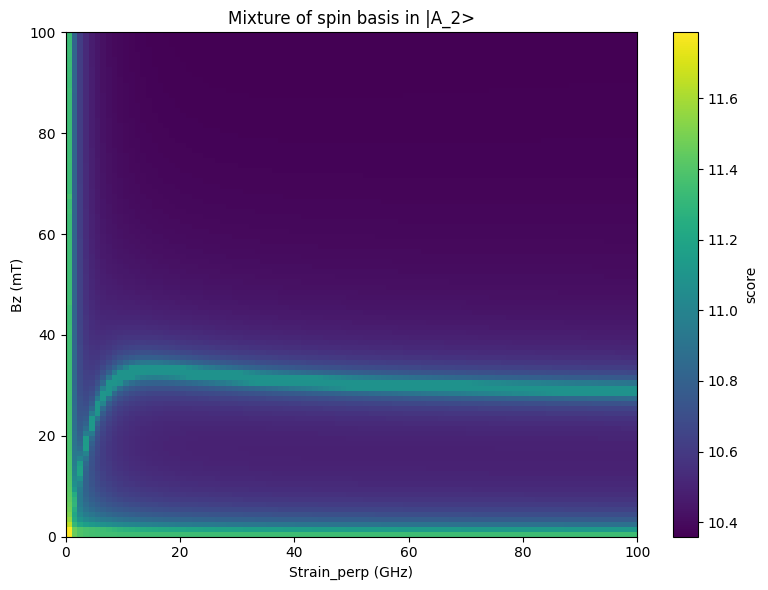

C:\Users\Tsuchiya Saki\AppData\Local\Temp\ipykernel_24996\3425506481.py:28: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  score_map[k, w] = score


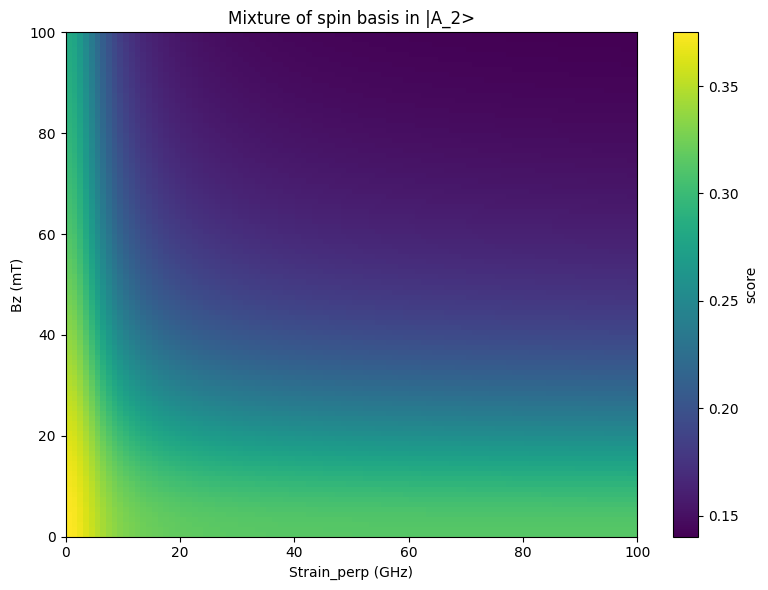

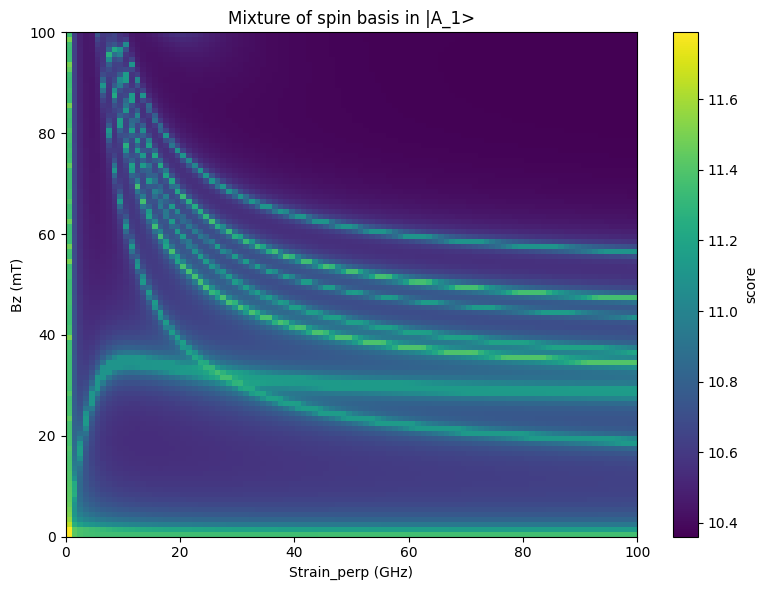

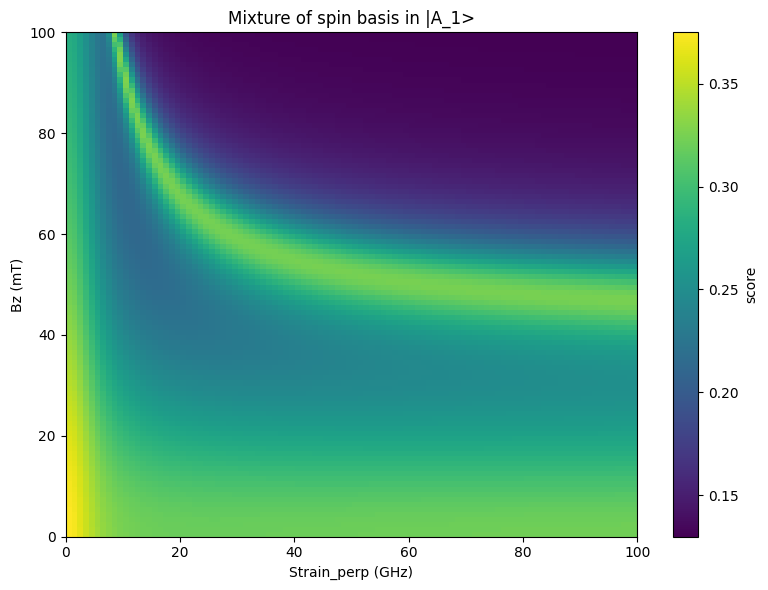

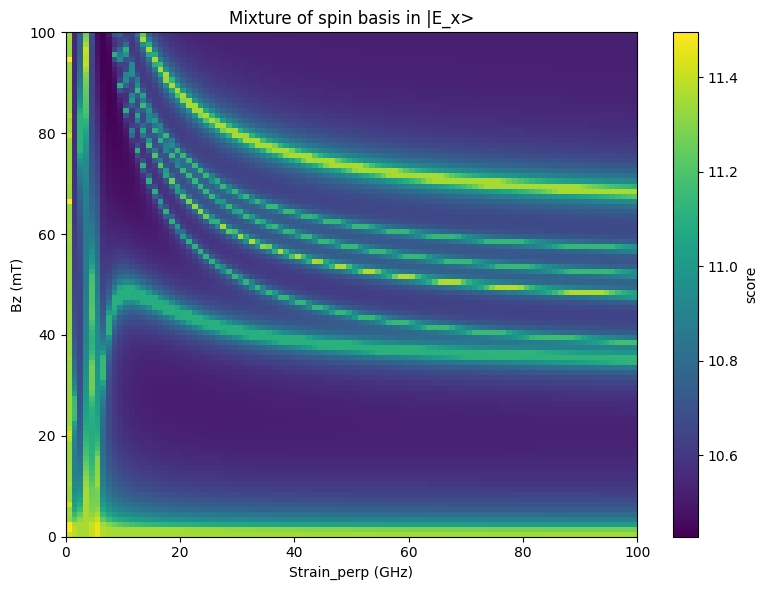

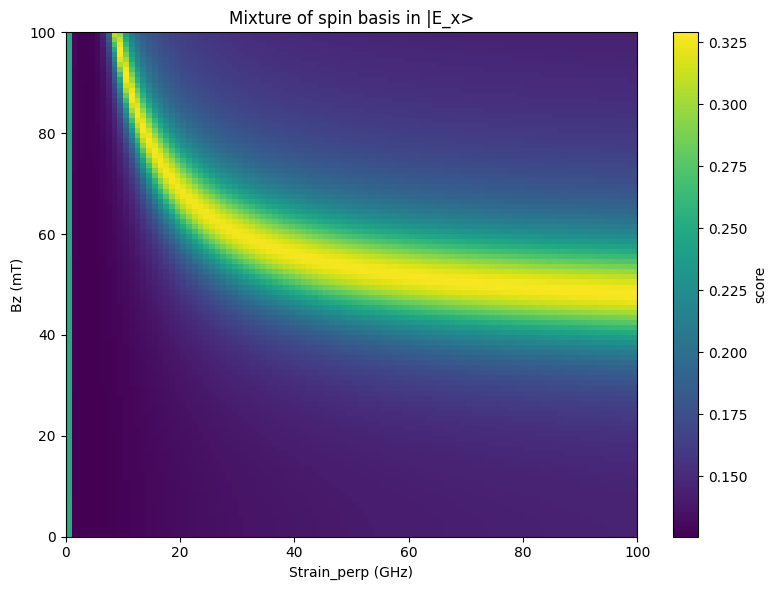

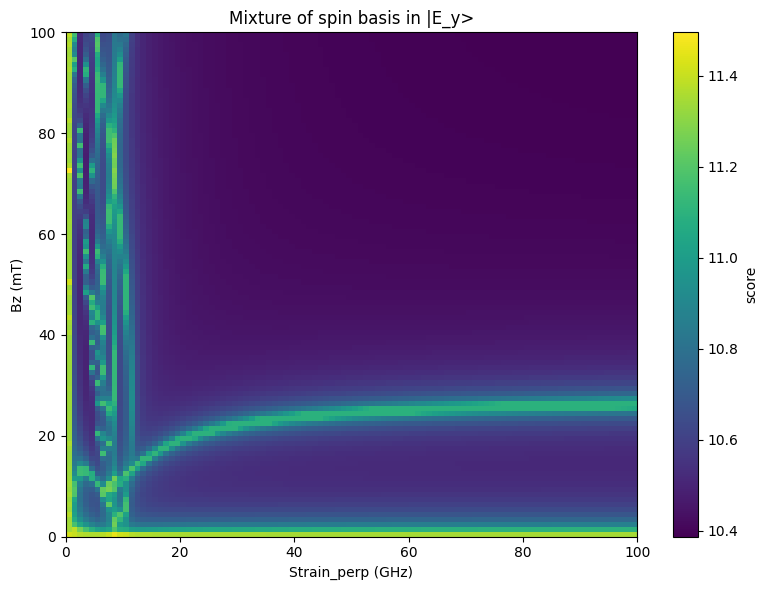

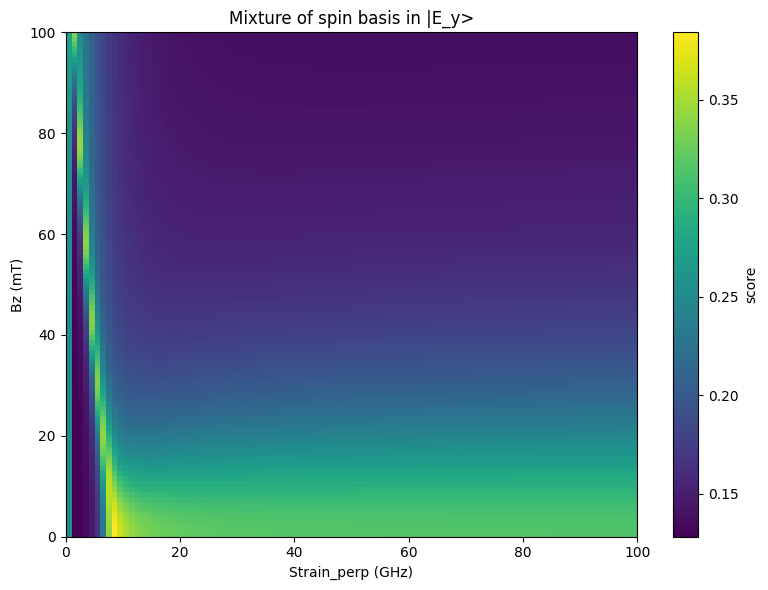

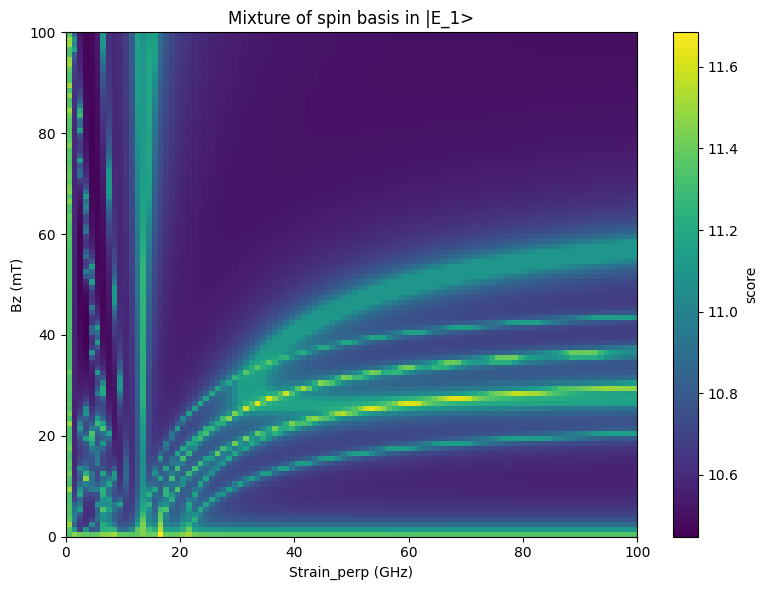

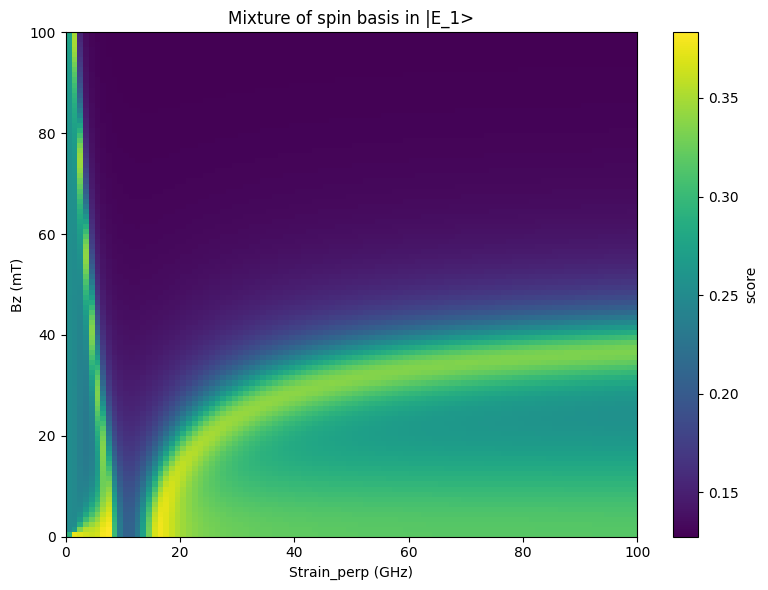

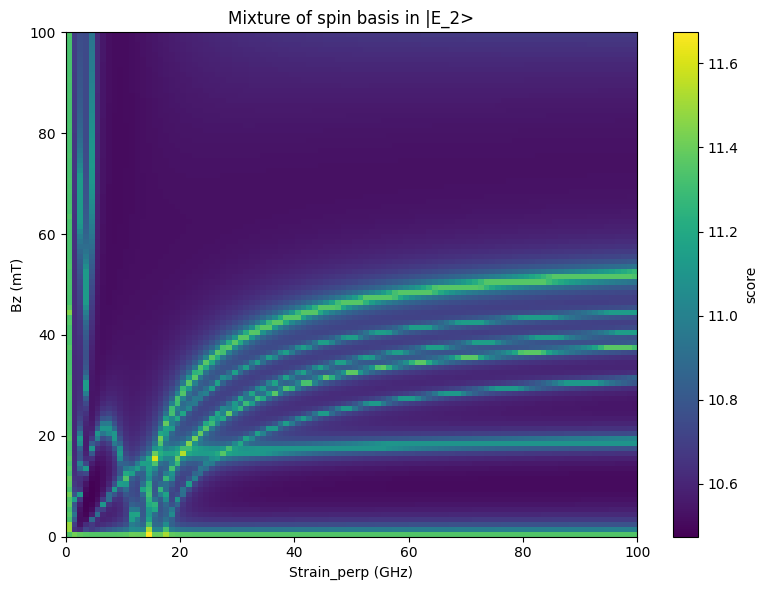

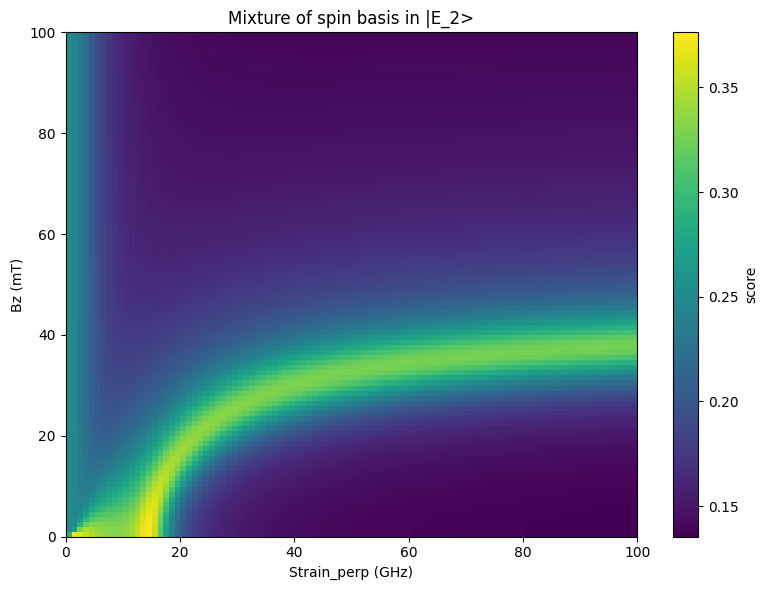

In [20]:

for spin_basis in range(6):
    map_spin_fun_Xi(spin_basis)
    map_spin_fun_Xi_pro(spin_basis)